# Retail Sales Data Analytic: Exploratory Data Analysis

## Project Overview

## Document Purpose

* Which product generate highest total revenue?
* Which countries generate the most revenue? (Excluding United Kingdom)
* What is the exact month-over-month (MoM) growth rate throughout the year?
* What percentage of our total sales comes from repeat buyers?
* Average Transaction Value(ATV) vs Unit Per Transaction(UPT)
* Average Customer Purchase Frequency


## Setup 

Before beginning the exploratory data analysis (EDA), we’ll load and prepare the cleaned dataset for analysis and visualization.

In [2]:
# modules we'll use
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# set defualt setting
sns.set_theme(style="whitegrid", font_scale=1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
ACCENT = "#2E5C8A"
ACCENT2 = "#E8813A"

def money(x, pos=None):
    """Formatter for currency axis labels ($1.2K, $3.4M ...)."""
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:.0f}"

# set project root
project_root = os.getcwd()
if os.path.basename(project_root) == "noteboook":
    project_root = os.path.dirname(project_root)

file_path = os.path.join(project_root, "data", "cleaned", "cleaned_retail_sales.xlsx")

try:
    df = pd.read_excel(file_path).copy()
except ImportError as error:
    raise ImportError("Install openpyxl first: pip install openpyxl") from error

# set seed for reproducibility
np.random.seed(0)

# preview 10 rows of cleaned dataset
df.head(10)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


## 1. Which product generate the highest total revenue?

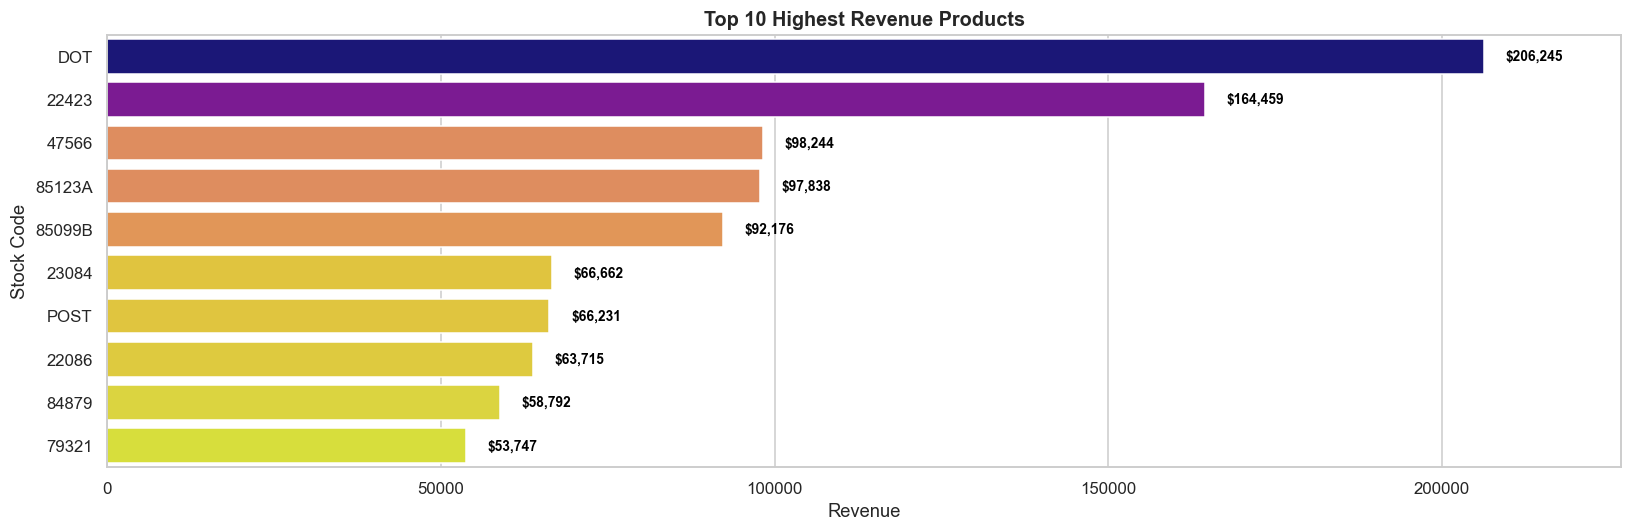

In [3]:
df['total_revenue'] = df['unit_price'] * df['quantity']
high_rev_prod = df.groupby('stock_code')['total_revenue'].sum().reset_index().sort_values(by='total_revenue', ascending=False).head(10)

fig, axes = plt.subplots(figsize=(15, 5))

sns.barplot(
    data=high_rev_prod,
    x='total_revenue',
    y='stock_code',
    hue='total_revenue',
    palette='plasma_r',
    legend=False,
    ax=axes,
)

for patch in axes.patches:
    width = patch.get_width()
    if width > 0:
        axes.text(
            x=width + (axes.get_xlim()[1] * 0.015),       
            y=patch.get_y() + patch.get_height() / 2,     
            s=f"${width:,.0f}",                           
            ha='left', 
            va='center', 
            fontsize=9, 
            fontweight='semibold',
            color="#000000"
        )

axes.margins(x=0.10)

plt.title("Top 10 Highest Revenue Products")
plt.xlabel('Revenue')
plt.ylabel('Stock Code')

plt.tight_layout()
plt.show()

## 2. Which country generate the most revenue? (Excluding United Kingdom)

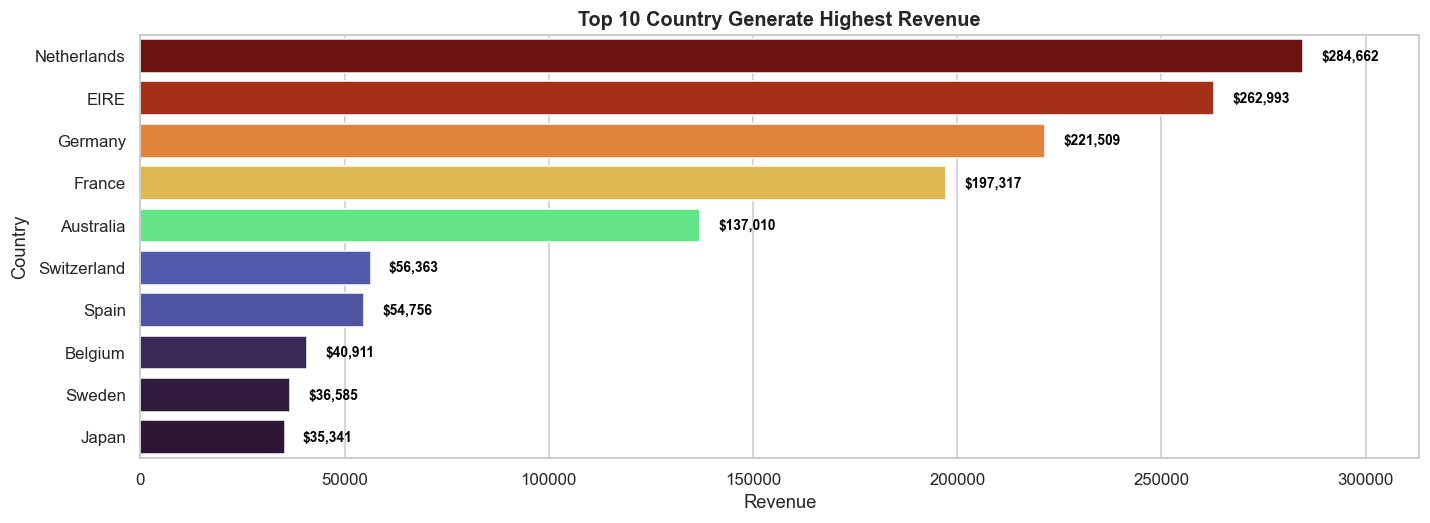

In [4]:
df_exclude_uk = df.copy()
df_exclude_uk = df_exclude_uk[df_exclude_uk['country'] != 'United Kingdom']
top_country = df_exclude_uk.groupby('country')['total_revenue'].sum().reset_index().sort_values(by='total_revenue', ascending=False).head(10)

fig, axes = plt.subplots(figsize=(15, 5))

sns.barplot(
    data=top_country,
    x='total_revenue',
    y='country',
    hue='total_revenue',
    palette='turbo',
    legend=False,
    ax=axes,
)

for patch in axes.patches:
    width = patch.get_width()
    if width > 0:
        axes.text(
            x=width + (axes.get_xlim()[1] * 0.015),       
            y=patch.get_y() + patch.get_height() / 2,     
            s=f"${width:,.0f}",                           
            ha='left', 
            va='center', 
            fontsize=9, 
            fontweight='semibold',
            color="#000000"
        )

axes.margins(x=0.10)

plt.title("Top 10 Country Generate Highest Revenue")
plt.xlabel('Revenue')
plt.ylabel('Country')

plt.tight_layout
plt.show()

## 3. What is the exact month-over-month (MoM) growth rate throughout the year?

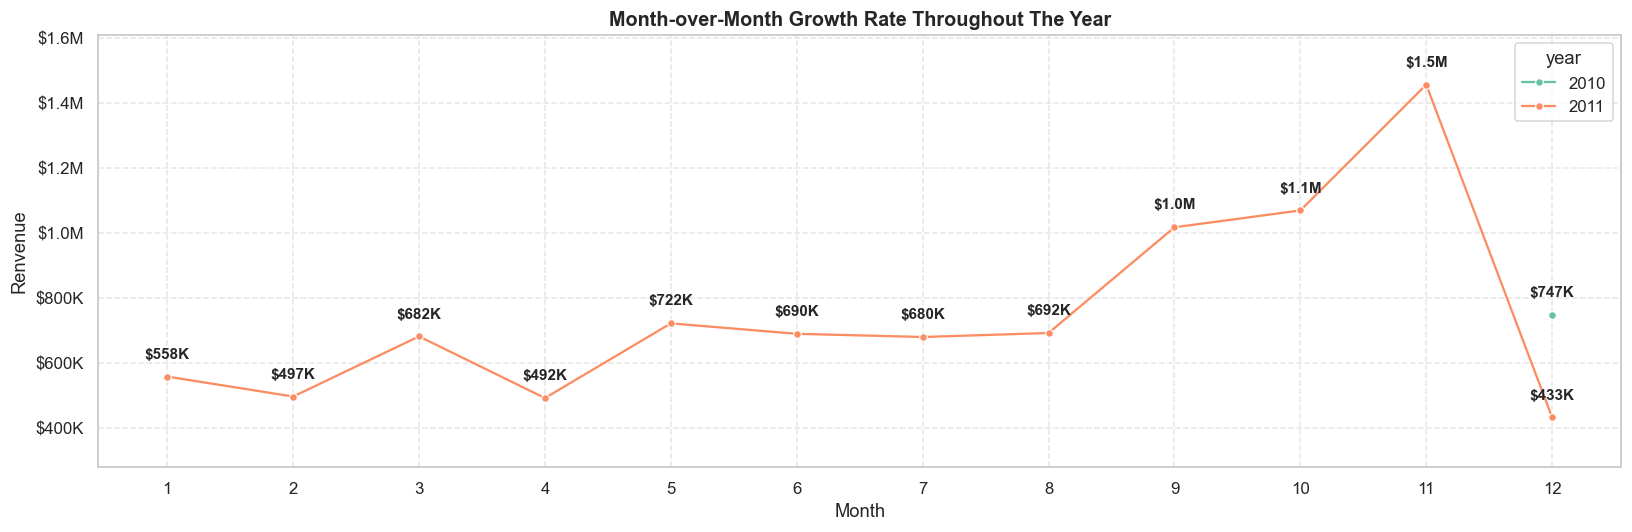

In [41]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month
mom = (df.groupby(['year', 'month'])['total_revenue'].sum().reset_index())

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=mom,
    x='month',
    y='total_revenue',
    hue='year',
    palette='Set2',
    marker='o',
    markersize=5
)

for index, row in mom.iterrows():
    value = row['total_revenue']
    if value >= 1e6:
        label = f'${value*1e-6:.1f}M'
    elif value >= 1e3:
        label = f'${value*1e-3:.0f}K'
    else:
        label = f'${value:.0f}'
        
    plt.annotate(
        text=label,
        xy=(row['month'], value),    
        xytext=(0, 10),                   
        textcoords='offset points',        
        va='bottom',      
        ha='center',      
        fontsize=10,
        fontweight='bold'
    )

def format_currency(x, pos):
    if x >= 1e6:
        return f'${x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x*1e-3:.0f}K'
    return f'${x:.0f}'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_currency))

plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.5)
plt.title("Month-over-Month Growth Rate Throughout The Year")
plt.xlabel('Month')
plt.ylabel('Renvenue')
plt.margins(y=0.15)

plt.tight_layout()
plt.show()

## 4. What percentage of our total sales comes from repeat buyers?

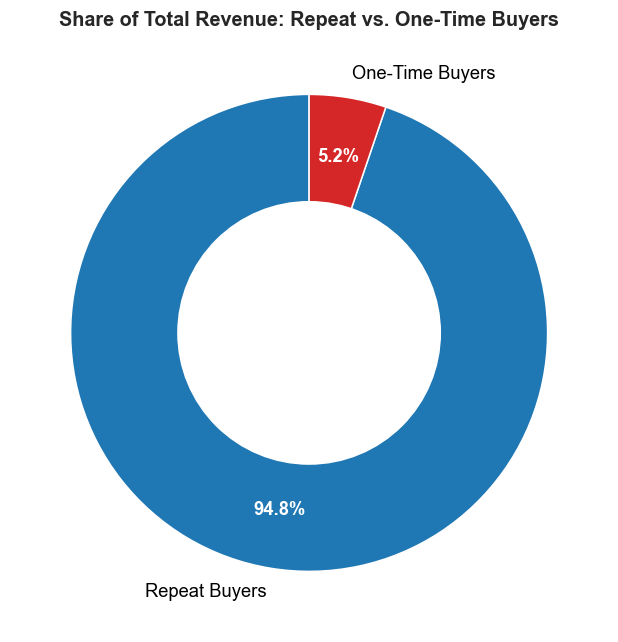

In [6]:
cust_sales = df.groupby('customer_id').agg(total_spent=('total_revenue', 'sum'), purchase_count=('invoice_no', 'nunique')).reset_index()

total_sales = cust_sales['total_spent'].sum()
repeat_buyers_sales = cust_sales[cust_sales['purchase_count'] > 1]['total_spent'].sum()

repeat_sales_pct = (repeat_buyers_sales / total_sales) * 100

labels = ['Repeat Buyers', 'One-Time Buyers']
sizes = [repeat_buyers_sales, total_sales - repeat_buyers_sales]
colors = ['#1f77b4', '#d62728']

plt.figure(figsize=(6, 6))

wedges, texts, autotexts = plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%',   
    startangle=90,       
    colors=colors,
    textprops=dict(color="black", fontsize=12),
    pctdistance=0.75     
)

centre_circle = plt.Circle((0,0), 0.55, fc='white')

plt.gcf().gca().add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

plt.title("Share of Total Revenue: Repeat vs. One-Time Buyers")
plt.tight_layout()
plt.show()


## 5. Average Transaction Value(ATV) vs Unit Per Transaction(UPT)

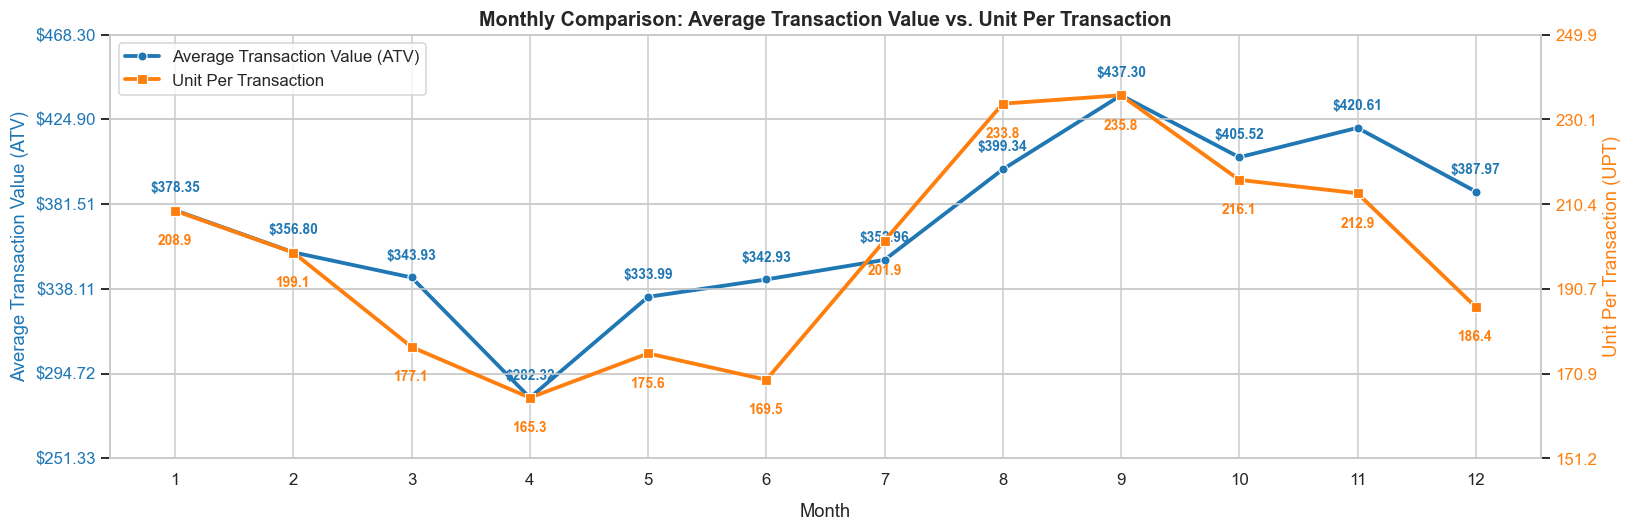

In [51]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

monthly_data = df.groupby(df['invoice_date'].dt.month).agg(
    total_rev=('total_revenue', 'sum'),
    total_qty=('quantity', 'sum'),
    unique_invoices=('invoice_no', 'nunique')
).reset_index()

monthly_data['atv'] = monthly_data['total_rev'] / monthly_data['unique_invoices']
monthly_data['upt'] = monthly_data['total_qty'] / monthly_data['unique_invoices']

fig, ax1 = plt.subplots(figsize=(15, 5))

color1 = '#1f77b4' 
sns.lineplot(
    data=monthly_data, 
    x='invoice_date', 
    y='atv', 
    ax=ax1, 
    color=color1, 
    marker='o', 
    linewidth=2.5,
    label='Average Transaction Value (ATV)'
)
ax1.set_xlabel('Month', fontsize=12, labelpad=10)
ax1.set_ylabel('Average Transaction Value (ATV)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('$%1.2f'))

for index, row in monthly_data.iterrows():
    ax1.annotate(
        text=f"${row['atv']:.2f}",
        xy=(row['invoice_date'], row['atv']),
        xytext=(0, 10),
        textcoords='offset points',
        va='bottom', ha='center',
        color=color1, fontweight='bold', fontsize=9
    )
ax1.margins(y=0.2)

ax2 = ax1.twinx() 
color2 = '#ff7f0e'
sns.lineplot(
    data=monthly_data, 
    x='invoice_date', 
    y='upt', 
    ax=ax2, 
    color=color2, 
    marker='s',
    linewidth=2.5,
    label='Unit Per Transaction'
)
ax2.set_ylabel('Unit Per Transaction (UPT)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%1.1f'))

for index, row in monthly_data.iterrows():
    ax2.annotate(
        text=f"{row['upt']:.1f}",
        xy=(row['invoice_date'], row['upt']),
        xytext=(0, -15),
        textcoords='offset points',
        va='top', ha='center',
        color=color2, fontweight='bold', fontsize=9
    )

ax2.margins(y=0.2)

plt.xticks(range(1, 13))
plt.title("Monthly Comparison: Average Transaction Value vs. Unit Per Transaction")

num_ticks = 6
ax1.yaxis.set_major_locator(ticker.LinearLocator(num_ticks))
ax2.yaxis.set_major_locator(ticker.LinearLocator(num_ticks))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.get_legend().remove()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.margins(x=0.50)
plt.tight_layout()
plt.show()


## 6. Average Customer Purchase Frequency

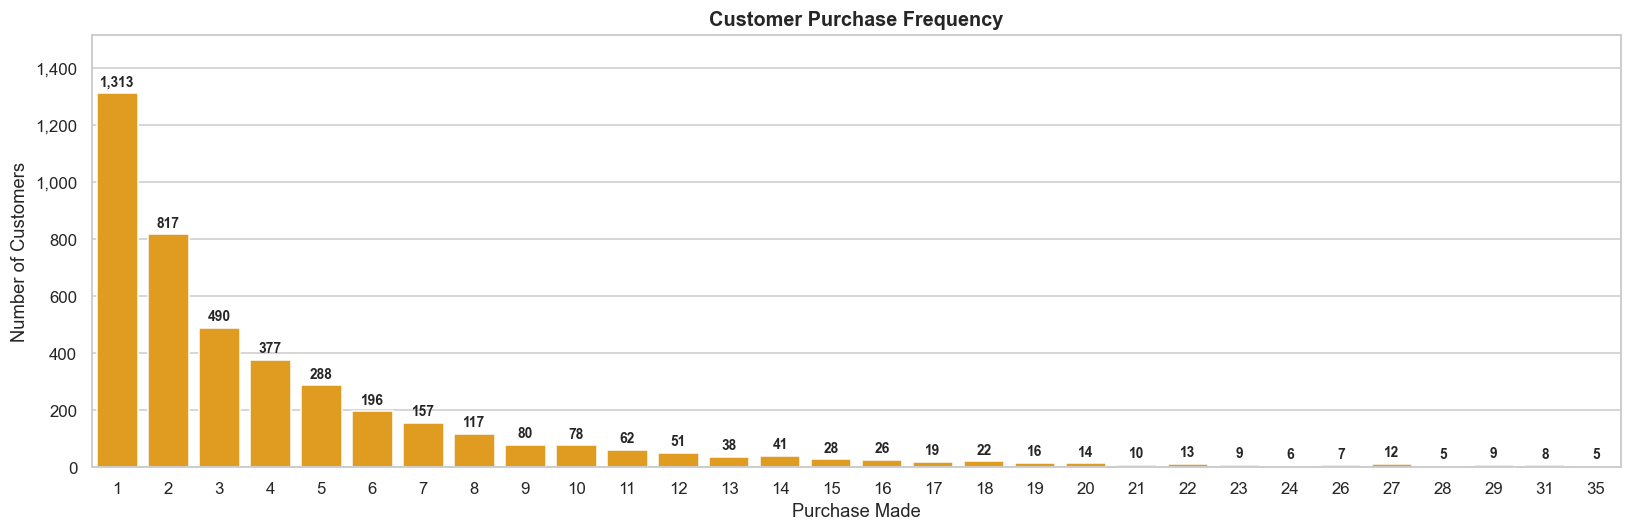

In [58]:
cus_counts= df.groupby('customer_id')['invoice_no'].nunique().reset_index()
cus_counts.columns = ['customer_id', 'purch_count']

freq_dist = cus_counts['purch_count'].value_counts().head(30).reset_index()
freq_dist.columns = ['purch_count', 'customer_count']
order_dist = freq_dist.sort_values(by='purch_count')

plt.figure(figsize=(15, 5))

sns.barplot(
    data=order_dist,
    x="purch_count",
    y="customer_count",
    color='orange'
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Purchase Made")
plt.ylabel("Number of Customers")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

current_ax = plt.gca()
for patch, val in zip(current_ax.patches, order_dist['customer_count']):
    if patch.get_height() > 0:
        current_ax.text(
            patch.get_x() + patch.get_width() / 2,     
            patch.get_height() + (current_ax.get_ylim()[1] * 0.01),
            f"{val:,.0f}",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='semibold'
        )

current_ax.set_ylim(top=current_ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()
